# Communities & Crime — EDA Overview

Quick exploratory analysis of the UCI Communities and Crime dataset. Each row represents a US community described by demographic, socioeconomic, and housing variables — the target is violent crime rate. The goal here is to give everyone a feel for the data so we can decide whether to use it for our project.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading & First Look

Basic shape of the dataset — how many rows, columns, and missing values we're dealing with.

In [2]:
crime = pd.read_csv('datasets/communities_crime.csv')
print(f"First row:\n{crime.head(1)}")
print(f"Number of rows: {len(crime)}")
print(f"Number of columns: {crime.columns.size}")
print(f"Number of nan values:\n{crime.isna().sum()}")

First row:
   population  householdsize  racepctblack  racePctWhite  racePctAsian  \
0        0.19           0.33          0.02           0.9          0.12   

   racePctHisp  agePct12t21  agePct12t29  agePct16t24  agePct65up  ...  \
0         0.17         0.34         0.47         0.29        0.32  ...   

   PctBornSameState  PctSameHouse85  PctSameCity85  PctSameState85  LandArea  \
0              0.42             0.5           0.51            0.64      0.12   

   PopDens  PctUsePubTrans  LemasPctOfficDrugUn  ViolentCrimesPerPop  \
0     0.26             0.2                 0.32                  0.2   

   HighViolentCrime  
0              High  

[1 rows x 102 columns]
Number of rows: 1994
Number of columns: 102
Number of nan values:
population             0
householdsize          0
racepctblack           0
racePctWhite           0
racePctAsian           0
                      ..
PopDens                0
PctUsePubTrans         0
LemasPctOfficDrugUn    0
ViolentCrimesPerPop    0
H

In [3]:
crime.columns.tolist()

['population',
 'householdsize',
 'racepctblack',
 'racePctWhite',
 'racePctAsian',
 'racePctHisp',
 'agePct12t21',
 'agePct12t29',
 'agePct16t24',
 'agePct65up',
 'numbUrban',
 'pctUrban',
 'medIncome',
 'pctWWage',
 'pctWFarmSelf',
 'pctWInvInc',
 'pctWSocSec',
 'pctWPubAsst',
 'pctWRetire',
 'medFamInc',
 'perCapInc',
 'whitePerCap',
 'blackPerCap',
 'indianPerCap',
 'AsianPerCap',
 'OtherPerCap',
 'HispPerCap',
 'NumUnderPov',
 'PctPopUnderPov',
 'PctLess9thGrade',
 'PctNotHSGrad',
 'PctBSorMore',
 'PctUnemployed',
 'PctEmploy',
 'PctEmplManu',
 'PctEmplProfServ',
 'PctOccupManu',
 'PctOccupMgmtProf',
 'MalePctDivorce',
 'MalePctNevMarr',
 'FemalePctDiv',
 'TotalPctDiv',
 'PersPerFam',
 'PctFam2Par',
 'PctKids2Par',
 'PctYoungKids2Par',
 'PctTeen2Par',
 'PctWorkMomYoungKids',
 'PctWorkMom',
 'NumIlleg',
 'PctIlleg',
 'NumImmig',
 'PctImmigRecent',
 'PctImmigRec5',
 'PctImmigRec8',
 'PctImmigRec10',
 'PctRecentImmig',
 'PctRecImmig5',
 'PctRecImmig8',
 'PctRecImmig10',
 'PctSpeakEng

### Variable Descriptions

| Column Name | Description | Column Name | Description |
|---|---|---|---|
| `population` | Total population of the community. | `PctImmigRec10` | Percent of immigrants who arrived within the last 10 years. |
| `householdsize` | Average number of people per household. | `PctRecentImmig` | Recent immigrants as a percent of total population. |
| `racepctblack` | Percent of population that is Black. | `PctRecImmig5` | Immigrants arriving within 5 years as percent of total population. |
| `racePctWhite` | Percent of population that is White. | `PctRecImmig8` | Immigrants arriving within 8 years as percent of total population. |
| `racePctAsian` | Percent of population that is Asian. | `PctRecImmig10` | Immigrants arriving within 10 years as percent of total population. |
| `racePctHisp` | Percent of population that is Hispanic. | `PctSpeakEnglOnly` | Percent of population that speaks only English. |
| `agePct12t21` | Percent of population aged 12 to 21. | `PctNotSpeakEnglWell` | Percent of population that does not speak English well. |
| `agePct12t29` | Percent of population aged 12 to 29. | `PctLargHouseFam` | Percent of family households that are large. |
| `agePct16t24` | Percent of population aged 16 to 24. | `PctLargHouseOccup` | Percent of occupied households that are large. |
| `agePct65up` | Percent of population aged 65 or older. | `PersPerOccupHous` | Average number of people per occupied household. |
| `numbUrban` | Number of people living in urban areas. | `PersPerOwnOccHous` | Average number of people per owner-occupied household. |
| `pctUrban` | Percent of population living in urban areas. | `PersPerRentOccHous` | Average number of people per renter-occupied household. |
| `medIncome` | Median household income. | `PctPersOwnOccup` | Percent of people living in owner-occupied housing. |
| `pctWWage` | Percent with wage or salary income. | `PctPersDenseHous` | Percent of people living in dense or crowded housing. |
| `pctWFarmSelf` | Percent with farm or self-employment income. | `PctHousLess3BR` | Percent of housing units with fewer than 3 bedrooms. |
| `pctWInvInc` | Percent with investment income. | `MedNumBR` | Median number of bedrooms. |
| `pctWSocSec` | Percent with Social Security income. | `HousVacant` | Number of vacant housing units. |
| `pctWPubAsst` | Percent with public assistance income. | `PctHousOccup` | Percent of housing units that are occupied. |
| `pctWRetire` | Percent with retirement income. | `PctHousOwnOcc` | Percent of housing units that are owner-occupied. |
| `medFamInc` | Median family income. | `PctVacantBoarded` | Percent of vacant housing that is boarded up. |
| `perCapInc` | Per-capita income for the community. | `PctVacMore6Mos` | Percent of vacant housing vacant for more than 6 months. |
| `whitePerCap` | Per-capita income among White residents. | `MedYrHousBuilt` | Median year housing units were built. |
| `blackPerCap` | Per-capita income among Black residents. | `PctHousNoPhone` | Percent of households without a phone. |
| `indianPerCap` | Per-capita income among American Indian residents. | `PctWOFullPlumb` | Percent of households without full plumbing. |
| `AsianPerCap` | Per-capita income among Asian residents. | `OwnOccLowQuart` | Lower quartile value of owner-occupied homes. |
| `OtherPerCap` | Per-capita income among residents categorized as other race. | `OwnOccMedVal` | Median value of owner-occupied homes. |
| `HispPerCap` | Per-capita income among Hispanic residents. | `OwnOccHiQuart` | Upper quartile value of owner-occupied homes. |
| `NumUnderPov` | Number of people below the poverty line. | `RentLowQ` | Lower quartile rent. |
| `PctPopUnderPov` | Percent of population below the poverty line. | `RentMedian` | Median rent. |
| `PctLess9thGrade` | Percent of adults with less than 9th grade education. | `RentHighQ` | Upper quartile rent. |
| `PctNotHSGrad` | Percent of adults who did not graduate high school. | `MedRent` | Median gross rent. |
| `PctBSorMore` | Percent of adults with a bachelor’s degree or higher. | `MedRentPctHousInc` | Median rent as a percent of household income. |
| `PctUnemployed` | Percent of labor force unemployed. | `MedOwnCostPctInc` | Median owner cost as a percent of income, with mortgage. |
| `PctEmploy` | Percent of population employed. | `MedOwnCostPctIncNoMtg` | Median owner cost as a percent of income, without mortgage. |
| `PctEmplManu` | Percent employed in manufacturing. | `NumInShelters` | Number of people living in shelters. |
| `PctEmplProfServ` | Percent employed in professional services. | `NumStreet` | Number of homeless people counted on the street. |
| `PctOccupManu` | Percent of occupations in manufacturing. | `PctForeignBorn` | Percent of population that is foreign-born. |
| `PctOccupMgmtProf` | Percent of occupations in management or professional jobs. | `PctBornSameState` | Percent born in the same state they currently live in. |
| `MalePctDivorce` | Percent of males who are divorced. | `PctSameHouse85` | Percent living in the same house since 1985. |
| `MalePctNevMarr` | Percent of males who have never married. | `PctSameCity85` | Percent living in the same city since 1985. |
| `FemalePctDiv` | Percent of females who are divorced. | `PctSameState85` | Percent living in the same state since 1985. |
| `TotalPctDiv` | Total percent of adults divorced. | `LandArea` | Land area of the community. |
| `PersPerFam` | Average number of people per family. | `PopDens` | Population density. |
| `PctFam2Par` | Percent of families headed by two parents. | `PctUsePubTrans` | Percent of people using public transportation. |
| `PctKids2Par` | Percent of children living in two-parent households. | `LemasPctOfficDrugUn` | Percent of police officers assigned to drug units. |
| `PctYoungKids2Par` | Percent of young children living in two-parent households. | `ViolentCrimesPerPop` | Violent crimes per population; usually the main regression target. |
| `PctTeen2Par` | Percent of teenagers living in two-parent households. | `HighViolentCrime` | Binary target variable for whether violent crime is high. |
| `PctWorkMomYoungKids` | Percent of mothers with young children who work. |  |  |
| `PctWorkMom` | Percent of mothers who work. |  |  |
| `NumIlleg` | Number of children born to unmarried parents. |  |  |
| `PctIlleg` | Percent of children born to unmarried parents. |  |  |
| `NumImmig` | Number of immigrants. |  |  |
| `PctImmigRecent` | Percent of immigrants who recently immigrated. |  |  |
| `PctImmigRec5` | Percent of immigrants who arrived within the last 5 years. |  |  |
| `PctImmigRec8` | Percent of immigrants who arrived within the last 8 years. |  |  |

The dataset does not include direct geographic identifiers such as city name, state, county, ZIP code, or area code. Instead, each row represents a community using demographic, socioeconomic, housing, and crime-related variables. This means the analysis focuses on patterns across community characteristics rather than identifying specific locations.

### Summary Statistics

In [4]:
crime.describe()

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
count,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,...,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000
mean,0.057593,0.463395,0.179629,0.753716,0.153681,0.144022,0.424218,0.493867,0.336264,0.423164,...,0.215552,0.608892,0.535050,0.626424,0.651530,0.065231,0.232854,0.161685,0.094052,0.237979
std,0.126906,0.163717,0.253442,0.244039,0.208877,0.232492,0.155196,0.143564,0.166505,0.179185,...,0.231134,0.204329,0.181352,0.200521,0.198221,0.109459,0.203092,0.229055,0.240328,0.232985
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.010000,0.350000,0.020000,0.630000,0.040000,0.010000,0.340000,0.410000,0.250000,0.300000,...,0.060000,0.470000,0.420000,0.520000,0.560000,0.020000,0.100000,0.020000,0.000000,0.070000
50%,0.020000,0.440000,0.060000,0.850000,0.070000,0.040000,0.400000,0.480000,0.290000,0.420000,...,0.130000,0.630000,0.540000,0.670000,0.700000,0.040000,0.170000,0.070000,0.000000,0.150000
75%,0.050000,0.540000,0.230000,0.940000,0.170000,0.160000,0.470000,0.540000,0.360000,0.530000,...,0.280000,0.777500,0.660000,0.770000,0.790000,0.070000,0.280000,0.190000,0.000000,0.330000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Distributions

Histograms for a representative subset of the numeric features.

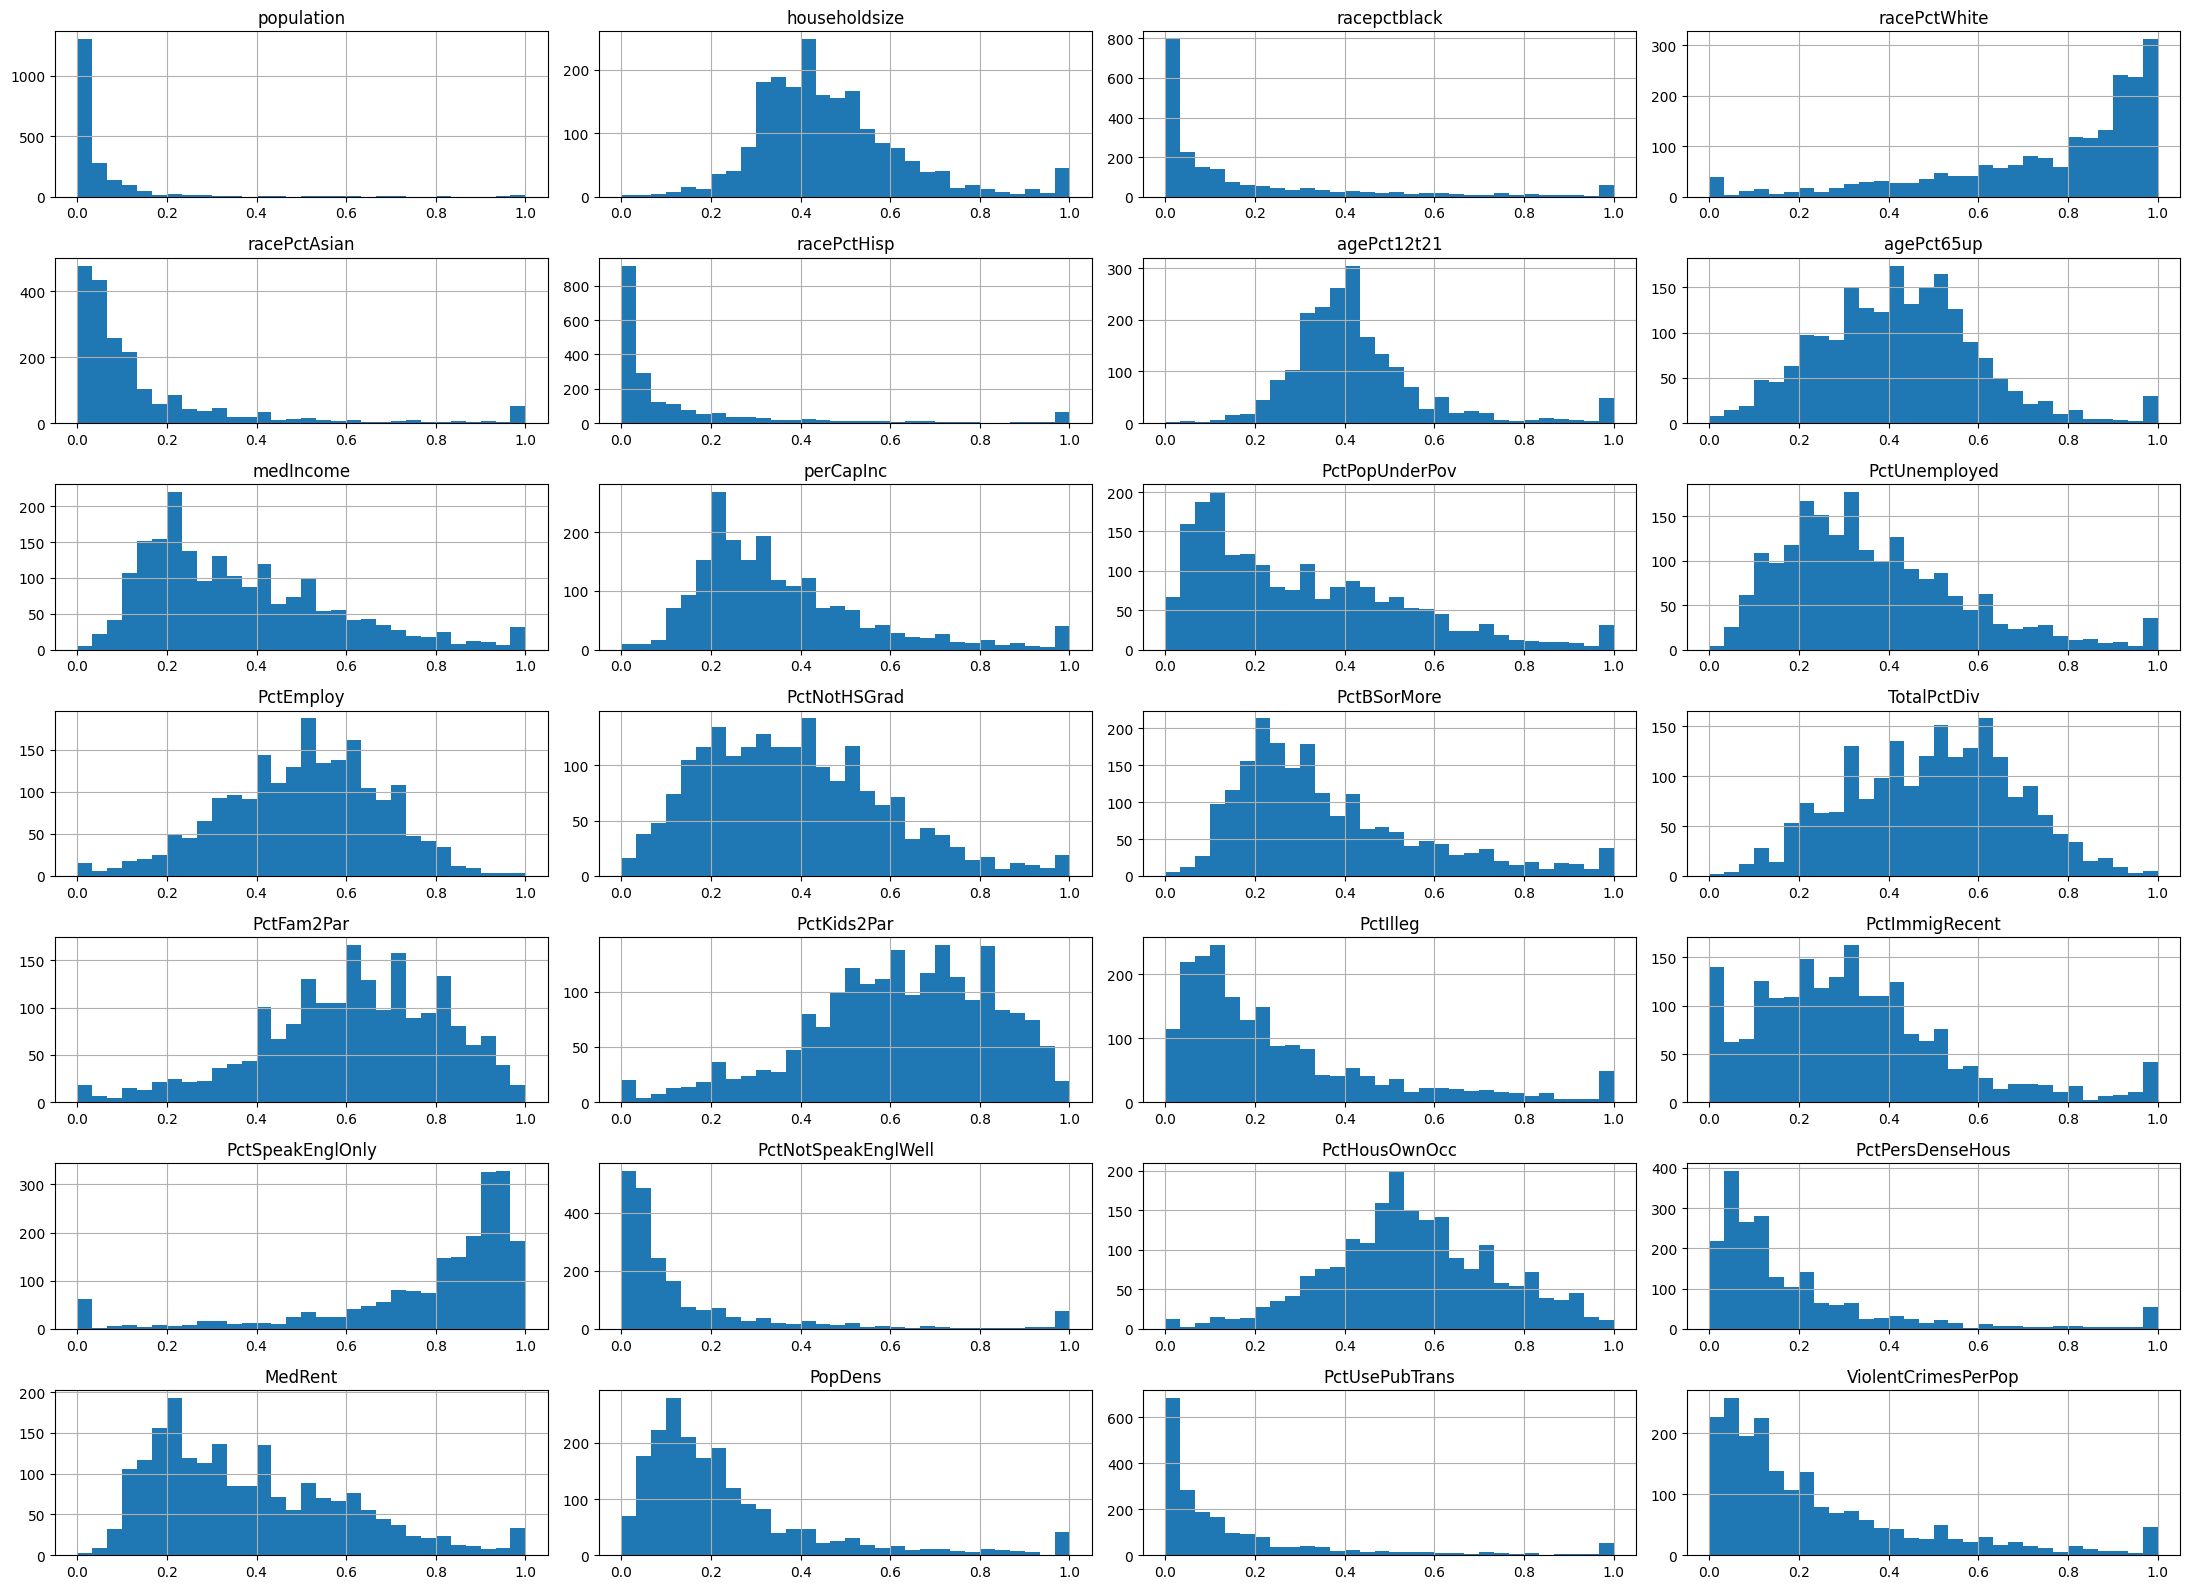

In [5]:
cols = [
    'population', 'householdsize', 'racepctblack', 'racePctWhite',
    'racePctAsian', 'racePctHisp', 'agePct12t21', 'agePct65up',
    'medIncome', 'perCapInc', 'PctPopUnderPov', 'PctUnemployed',
    'PctEmploy', 'PctNotHSGrad', 'PctBSorMore', 'TotalPctDiv',
    'PctFam2Par', 'PctKids2Par', 'PctIlleg', 'PctImmigRecent',
    'PctSpeakEnglOnly', 'PctNotSpeakEnglWell', 'PctHousOwnOcc',
    'PctPersDenseHous', 'MedRent', 'PopDens', 'PctUsePubTrans',
    'ViolentCrimesPerPop'
]

crime[cols].hist(figsize=(22, 16), bins=30, layout=(7, 4))

plt.tight_layout()
plt.show()

The histogram grid shows that many variables in the crime dataset are skewed rather than normally distributed. Several variables, such as population, population density, public transportation use, dense housing, and violent crimes per population, are strongly right-skewed, meaning most communities have low values while a smaller number have much higher values. Some variables, such as percent White, percent English-speaking only, percent of children in two-parent households, and percent owner-occupied housing, are left-skewed and concentrated near higher values. Overall, the histograms suggest substantial variation across communities and show that preprocessing or scaling may be important before applying multivariate methods.

## Target Variable

The dataset has both a continuous target (`ViolentCrimesPerPop`) and a binary one (`HighViolentCrime`). How balanced is the binary target?

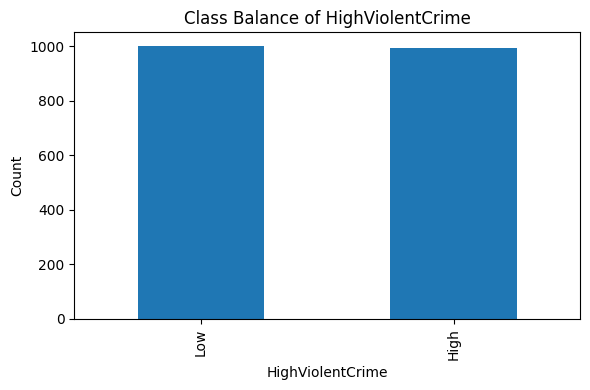

In [6]:
crime['HighViolentCrime'].value_counts().plot(kind='bar', figsize=(6, 4))

plt.title('Class Balance of HighViolentCrime')
plt.xlabel('HighViolentCrime')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## High vs Low Crime Communities

How do community characteristics differ between the two crime categories?

### Mean Comparison

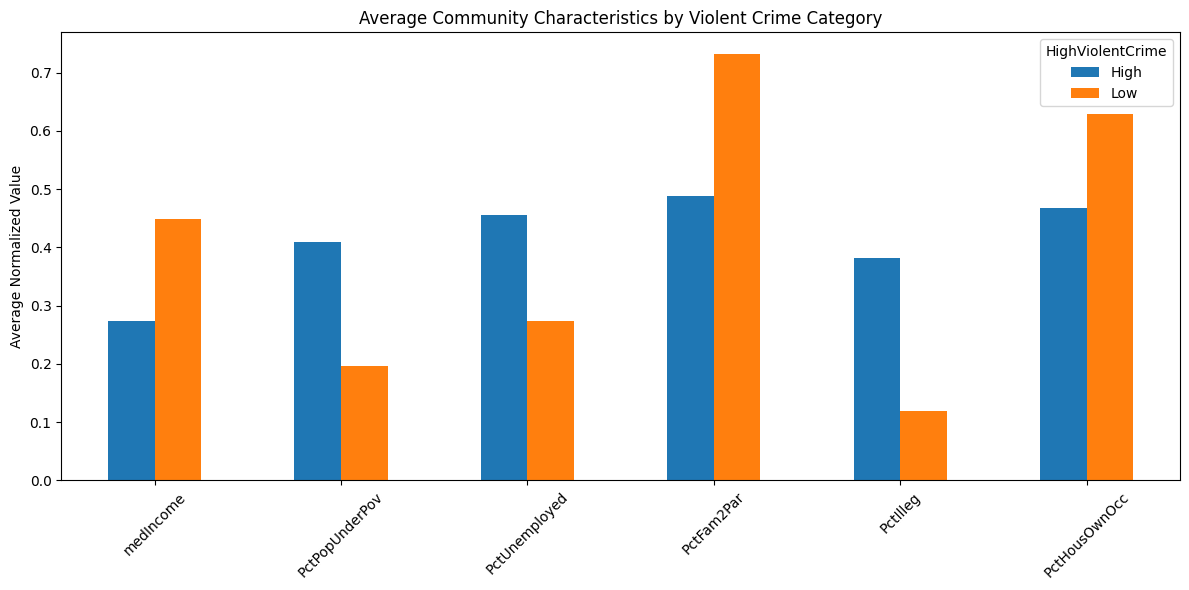

In [7]:
crime.groupby('HighViolentCrime')[['medIncome', 'PctPopUnderPov', 'PctUnemployed', 
                                   'PctFam2Par', 'PctIlleg', 'PctHousOwnOcc']].mean().T.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Average Community Characteristics by Violent Crime Category')
plt.ylabel('Average Normalized Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Box Plots

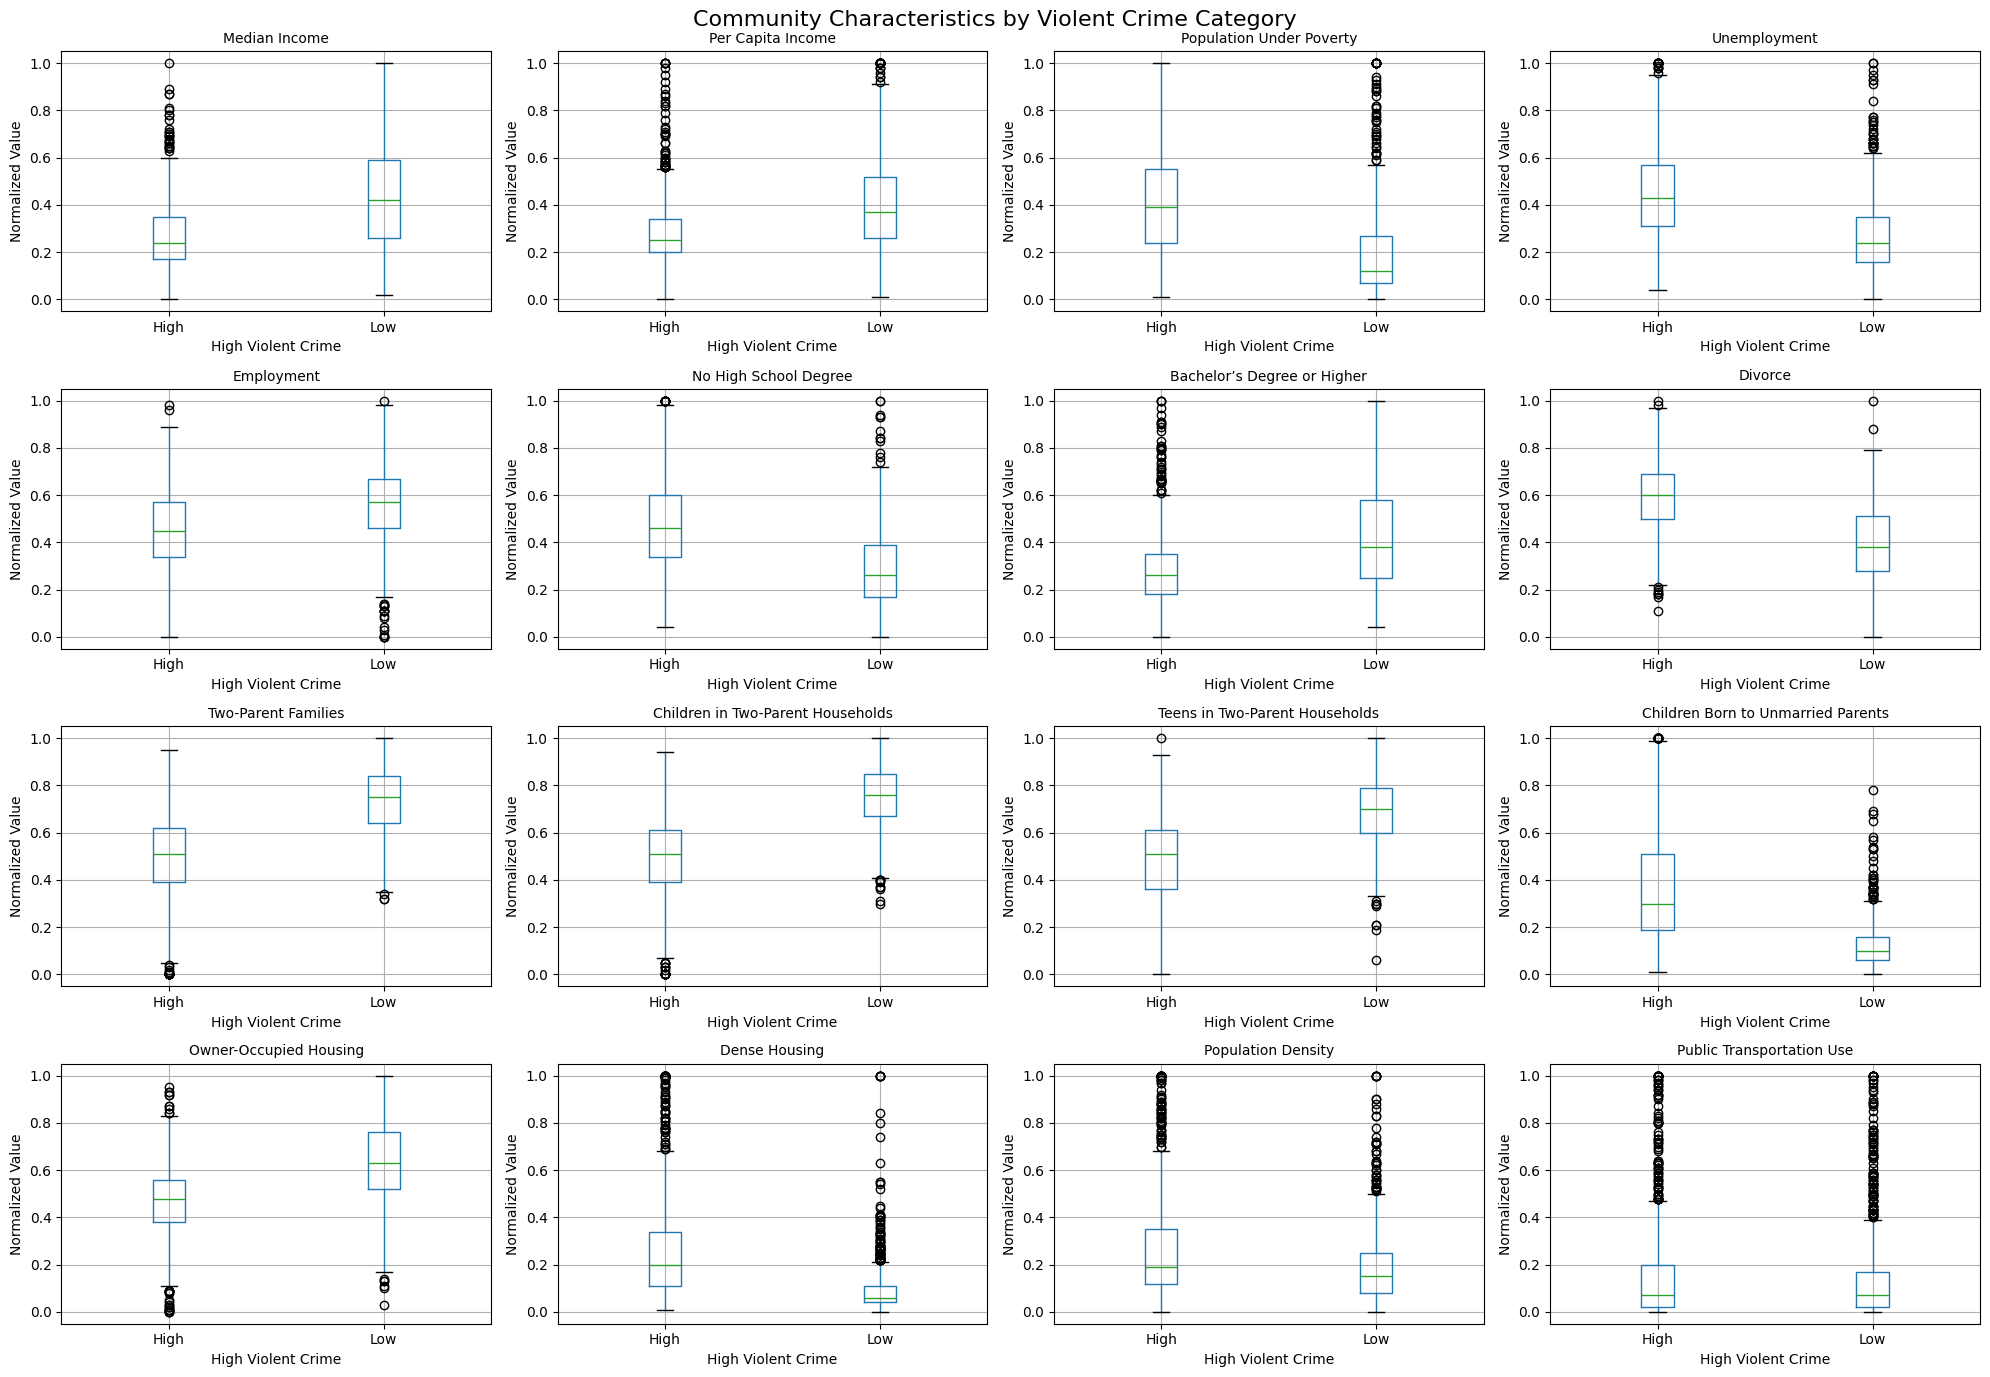

In [8]:
selected_cols = [
    'medIncome',
    'perCapInc',
    'PctPopUnderPov',
    'PctUnemployed',
    'PctEmploy',
    'PctNotHSGrad',
    'PctBSorMore',
    'TotalPctDiv',
    'PctFam2Par',
    'PctKids2Par',
    'PctTeen2Par',
    'PctIlleg',
    'PctHousOwnOcc',
    'PctPersDenseHous',
    'PopDens',
    'PctUsePubTrans'
]

titles = [
    'Median Income',
    'Per Capita Income',
    'Population Under Poverty',
    'Unemployment',
    'Employment',
    'No High School Degree',
    'Bachelor’s Degree or Higher',
    'Divorce',
    'Two-Parent Families',
    'Children in Two-Parent Households',
    'Teens in Two-Parent Households',
    'Children Born to Unmarried Parents',
    'Owner-Occupied Housing',
    'Dense Housing',
    'Population Density',
    'Public Transportation Use'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    crime.boxplot(
        column=col,
        by='HighViolentCrime',
        ax=axes[i]
    )
    
    axes[i].set_title(titles[i], fontsize=10)
    axes[i].set_xlabel('High Violent Crime')
    axes[i].set_ylabel('Normalized Value')

plt.suptitle('Community Characteristics by Violent Crime Category', fontsize=16)
plt.tight_layout()
plt.show()

## Correlations with Violent Crime

Which features are most strongly associated with the target?

### Top Positive & Negative Correlations

In [9]:
corrs = crime.corr(numeric_only=True)['ViolentCrimesPerPop'].sort_values()

strongest_negative = corrs.head(10)
strongest_positive = corrs.tail(10)

strongest_negative, strongest_positive

(PctKids2Par        -0.738424
 PctFam2Par         -0.706667
 racePctWhite       -0.684770
 PctYoungKids2Par   -0.666059
 PctTeen2Par        -0.661582
 pctWInvInc         -0.576324
 PctPersOwnOccup    -0.525491
 PctHousOwnOcc      -0.470683
 medFamInc          -0.439108
 medIncome          -0.424221
 Name: ViolentCrimesPerPop, dtype: float64,
 PctHousNoPhone         0.488243
 PctUnemployed          0.504235
 PctPopUnderPov         0.521877
 MalePctDivorce         0.525407
 TotalPctDiv            0.552777
 FemalePctDiv           0.556032
 pctWPubAsst            0.574665
 racepctblack           0.631264
 PctIlleg               0.737957
 ViolentCrimesPerPop    1.000000
 Name: ViolentCrimesPerPop, dtype: float64)

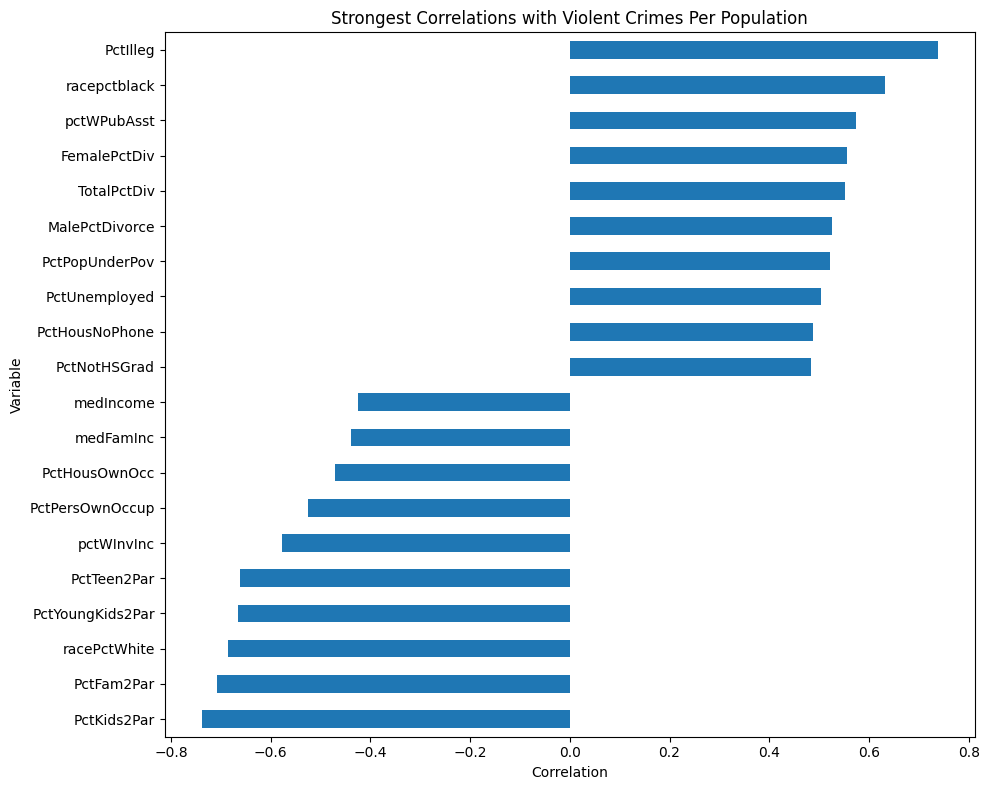

In [10]:
corrs = crime.corr(numeric_only=True)['ViolentCrimesPerPop']

corrs = corrs.drop(
    ['ViolentCrimesPerPop', 'HighViolentCrime'],
    errors='ignore'
)

corrs = corrs.sort_values()

top_corrs = pd.concat([corrs.head(10), corrs.tail(10)])

plt.figure(figsize=(10, 8))
top_corrs.plot(kind='barh')

plt.title('Strongest Correlations with Violent Crimes Per Population')
plt.xlabel('Correlation')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

### Correlation Heatmap

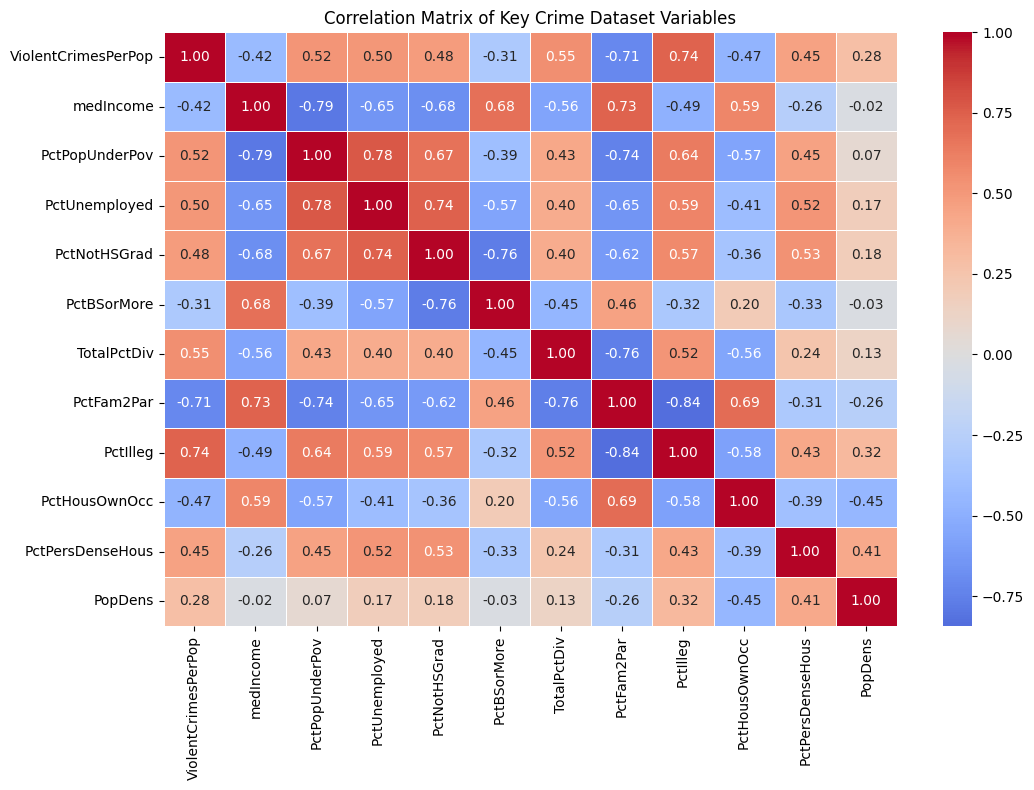

In [11]:
selected_cols = [
    'ViolentCrimesPerPop',
    'medIncome',
    'PctPopUnderPov',
    'PctUnemployed',
    'PctNotHSGrad',
    'PctBSorMore',
    'TotalPctDiv',
    'PctFam2Par',
    'PctIlleg',
    'PctHousOwnOcc',
    'PctPersDenseHous',
    'PopDens'
]

corr_matrix = crime[selected_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Key Crime Dataset Variables')
plt.tight_layout()
plt.show()

## EDA Summary: Communities and Crime Dataset

The Communities and Crime dataset contains 1,994 observations and 102 columns. Each row represents a U.S. community, and the variables describe demographic, socioeconomic, education, employment, family-structure, housing, geographic, law-enforcement, and crime-related characteristics. The dataset has no missing values, so the analysis can proceed without imputation or row removal.

The histogram grid shows that many variables are not normally distributed. Several variables, including `population`, `racepctblack`, `racePctAsian`, `racePctHisp`, `PctPersDenseHous`, `PopDens`, `PctUsePubTrans`, and `ViolentCrimesPerPop`, are strongly right-skewed. This means most communities have relatively low values for these variables, while a smaller number have much higher values. Other variables, such as `racePctWhite`, `PctSpeakEnglOnly`, `PctKids2Par`, and `PctHousOwnOcc`, are concentrated toward higher values.

The target variable `HighViolentCrime` is nearly balanced between the `High` and `Low` classes. This makes the dataset appropriate for supervised classification because the model is not heavily biased toward one class.

The group comparison bar chart shows that high-crime communities tend to have lower median income and lower owner-occupied housing, while having higher poverty, unemployment, and percentage of children born to unmarried parents. Low-crime communities tend to have higher two-parent family structure and higher housing ownership.

The boxplot grid provides a more detailed comparison between high- and low-crime communities. High-crime communities generally have lower income, lower employment, lower bachelor’s degree attainment, weaker two-parent family structure, and lower owner-occupied housing. They also tend to have higher poverty, unemployment, lower education, divorce, children born to unmarried parents, dense housing, and population density.

The correlation bar chart shows that `ViolentCrimesPerPop` is positively correlated with variables such as `PctIlleg`, public assistance, divorce, poverty, unemployment, lack of phone access, and lower education. It is negatively correlated with two-parent family variables, income, owner-occupied housing, and investment income. These patterns suggest that violent crime is associated with broader socioeconomic disadvantage, family structure, and housing stability.

Overall, the EDA suggests that violent crime is not related to just one variable. Instead, it appears connected to multiple community-level patterns, including income, poverty, education, family structure, housing, and demographic composition. These findings support using both multivariate methods and supervised prediction methods.

## Potential Research Questions Based on EDA

| Research Question | EDA Motivation | Possible Methods |
|---|---|---|
| Can socioeconomic, family-structure, and housing variables explain and predict whether a U.S. community has high violent crime? | The boxplots and bar chart show clear differences between high- and low-crime communities in income, poverty, unemployment, family structure, and housing ownership. | PCA, logistic regression, LDA, random forest |
| Which community characteristics are most strongly associated with violent crime rates? | The correlation bar chart shows strong positive and negative relationships between `ViolentCrimesPerPop` and variables related to poverty, income, family structure, and housing. | Correlation analysis, scatter plots, multiple regression |
| Do high-crime and low-crime communities differ more strongly in socioeconomic variables or family-structure variables? | The EDA shows both economic differences and family-structure differences, especially for `PctIlleg`, `PctFam2Par`, `PctKids2Par`, poverty, and income. | Group means, boxplots, LDA, logistic regression |
| Can communities be grouped into meaningful socioeconomic profiles, and do those profiles differ in violent crime levels? | The histograms and boxplots suggest large variation across communities, making clustering useful for identifying community profiles. | PCA, K-means clustering, hierarchical clustering |
| Can a smaller number of latent community factors summarize the 100+ variables and still explain violent crime patterns? | Many variables are related to broader themes such as economic disadvantage, education, family structure, and housing stability. | PCA, factor analysis, regression using PCs/factors |